# Phase 6, Milestone 5: continuous corridor occupation laws and prices

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_5_CORRIDOR_OCCUPATION.md`. It verifies:

1. the **arcsine anchor**: the driftless half-line occupation law from
   the FK resolvent against Lévy's exact arcsine density — a
   non-Gaussian benchmark;
2. the **atom at \(T\)** for a bounded corridor (never-exit
   probability): absorbing-boundary PDE against Monte Carlo;
3. **corridor digital and call prices** from the atom-separated
   Fourier density against exact-skeleton Monte Carlo, two step
   sizes;
4. convergence in Fourier modes and PDE grid.

Seed `20260727`. Monte Carlo appears only as an independent
benchmark; the pricing path is deterministic.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_corridor.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_corridor.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_corridor as pc

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. The arcsine anchor (driftless half-line)

With \(\mu=0\), corridor \([0,\infty)\), \(x_0=0\), the occupation
fraction follows Lévy's arcsine law — an exact benchmark built from
no Gaussian integrals.

atom (should be 0): 0.00e+00
mass: 1.00000000


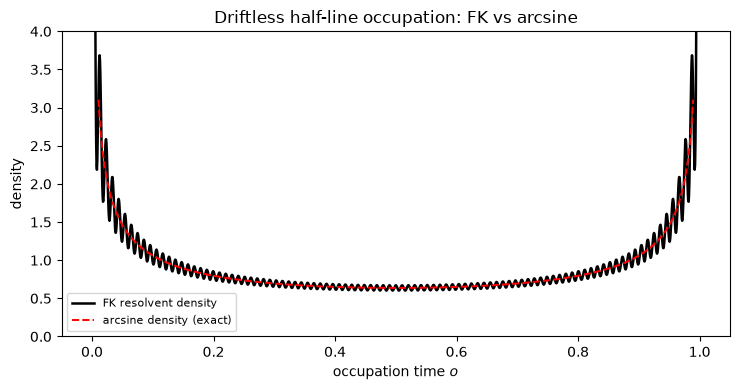

In [2]:
T_ARC = 1.0
o_arc, p_arc, atom_arc = pc.corridor_density_grid(
    maturity=T_ARC, x_lower=0.0, x_upper=50.0, x0=0.0,
    drift=0.0, volatility=1.0, n_modes=96, n_points=1601, n_grid=800,
)
print(f"atom (should be 0): {atom_arc:.2e}")
print(f"mass: {np.trapezoid(p_arc, o_arc):.8f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(o_arc, p_arc, "k-", lw=1.8, label="FK resolvent density")
inner = (o_arc > 0.01) & (o_arc < T_ARC - 0.01)
ax.plot(o_arc[inner], 1.0 / (np.pi * np.sqrt(o_arc[inner] * (T_ARC - o_arc[inner]))),
        "r--", lw=1.4, label="arcsine density (exact)")
ax.set_ylim(0, 4)
ax.set_xlabel(r"occupation time $o$"); ax.set_ylabel("density")
ax.set_title("Driftless half-line occupation: FK vs arcsine")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_corridor_arcsine.png", dpi=150)
plt.show()

## 2. Bounded corridor: the atom at \(T\)

For a bounded corridor, \(P(\mathcal O_T=T)>0\) (never exit). The
absorbing-boundary PDE computes it deterministically; Monte Carlo
confirms it. The Fourier density then carries mass \(1-\)atom.

atom PDE: 0.756538
atom MC : 0.765445 ± 0.001895 (2 SE; MC biased up by bridge misses)


continuous mass 0.243462 (target 0.243462)
first moment 0.953128 vs anchor 0.959969


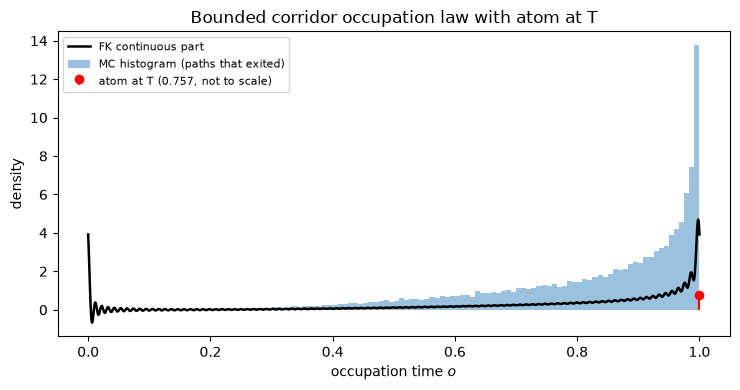

In [3]:
CASE = dict(maturity=1.0, x_lower=-1.0, x_upper=1.5, x0=0.0, drift=0.3, volatility=0.8)
T = CASE["maturity"]

def simulate_occupation(n_paths, step, seed, case):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(case["maturity"] / step))
    state = np.full(n_paths, case["x0"])
    inside_prev = np.ones(n_paths, dtype=bool)
    occ = np.zeros(n_paths)
    ever_out = np.zeros(n_paths, dtype=bool)
    sd = case["volatility"] * np.sqrt(step)
    for _ in range(n_steps):
        state = state + case["drift"] * step + sd * local_rng.standard_normal(n_paths)
        inside = (state >= case["x_lower"]) & (state <= case["x_upper"])
        occ += 0.5 * (inside_prev.astype(float) + inside.astype(float)) * step
        ever_out |= ~inside
        inside_prev = inside
    return occ, ~ever_out

occ_mc, stay_mc = simulate_occupation(200_000, 1e-3, SEED, CASE)
atom_pde = pc.corridor_survival_atom(
    maturity=T, x_lower=CASE["x_lower"], x_upper=CASE["x_upper"],
    x0=CASE["x0"], drift=CASE["drift"], volatility=CASE["volatility"],
)
atom_mc = stay_mc.mean()
atom_mc_se = np.sqrt(atom_mc * (1 - atom_mc) / stay_mc.size)
print(f"atom PDE: {atom_pde:.6f}")
print(f"atom MC : {atom_mc:.6f} ± {2*atom_mc_se:.6f} (2 SE; MC biased up by bridge misses)")

o_grid, p_grid, atom = pc.corridor_density_grid(
    **CASE, n_modes=96, n_points=1601, n_grid=800
)
mass = np.trapezoid(p_grid, o_grid)
m1 = np.trapezoid(o_grid * p_grid, o_grid)
anchor = pc.mean_occupation(
    T, x_lower=CASE["x_lower"], x_upper=CASE["x_upper"],
    x0=CASE["x0"], drift=CASE["drift"], volatility=CASE["volatility"],
)
print(f"continuous mass {mass:.6f} (target {1-atom:.6f})")
print(f"first moment {m1 + atom*T:.6f} vs anchor {anchor:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(o_grid, p_grid, "k-", lw=1.8, label="FK continuous part")
ax.hist(occ_mc[~stay_mc], bins=120, range=(0, T), density=True,
        alpha=0.45, label="MC histogram (paths that exited)")
ax.stem([T], [atom], linefmt="r-", markerfmt="ro", basefmt=" ",
        label=f"atom at T ({atom:.3f}, not to scale)")
ax.set_xlabel(r"occupation time $o$"); ax.set_ylabel("density")
ax.set_title("Bounded corridor occupation law with atom at T")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase6_corridor_bounded.png", dpi=150)
plt.show()

## 3. Corridor digital and call prices vs. Monte Carlo

In [4]:
RATE = 0.05
print(f"{'product':>18} {'FK':>10} {'MC dt=1e-3':>12} {'MC dt=2.5e-4':>13} {'2 SE (fine)':>12}")
occ_fine, _ = simulate_occupation(200_000, 2.5e-4, SEED + 1, CASE)
discount = np.exp(-RATE * T)
for kappa in (0.5, 0.7, 0.9):
    fk = pc.corridor_digital_price(
        kappa, maturity=T, rate=RATE, o_grid=o_grid, p_grid=p_grid, atom=atom
    )
    mc_coarse = discount * (occ_mc >= kappa * T).mean()
    pay_fine = discount * (occ_fine >= kappa * T)
    se = pay_fine.std(ddof=1) / np.sqrt(pay_fine.size)
    print(f"{'digital k=' + str(kappa):>18} {fk:10.6f} {mc_coarse:12.6f} {pay_fine.mean():13.6f} {2*se:12.2e}")
for kappa in (0.5, 0.7):
    fk = pc.corridor_call_price(
        kappa, maturity=T, rate=RATE, o_grid=o_grid, p_grid=p_grid, atom=atom
    )
    mc_coarse = discount * np.clip(occ_mc / T - kappa, 0, None).mean()
    pay_fine = discount * np.clip(occ_fine / T - kappa, 0, None)
    se = pay_fine.std(ddof=1) / np.sqrt(pay_fine.size)
    print(f"{'call k=' + str(kappa):>18} {fk:10.6f} {mc_coarse:12.6f} {pay_fine.mean():13.6f} {2*se:12.2e}")

           product         FK   MC dt=1e-3  MC dt=2.5e-4  2 SE (fine)


     digital k=0.5   0.930485     0.937532      0.936913     5.18e-04
     digital k=0.7   0.897660     0.905199      0.903815     9.26e-04
     digital k=0.9   0.827193     0.834732      0.833933     1.40e-03
        call k=0.5   0.435693     0.439364      0.438958     4.38e-04
        call k=0.7   0.252453     0.254702      0.254463     3.41e-04


## 4. Convergence: Fourier modes and PDE grid

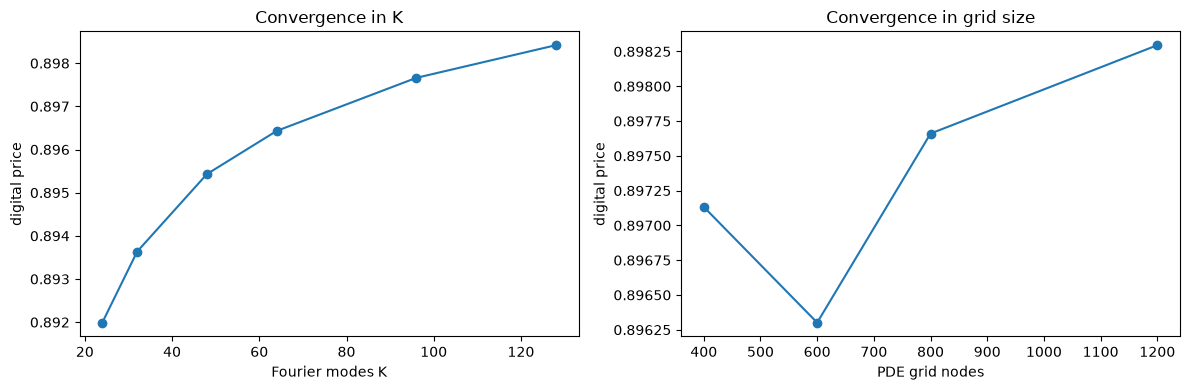

by K: ['0.891990', '0.893636', '0.895431', '0.896432', '0.897660', '0.898417']
by N: ['0.897133', '0.896301', '0.897660', '0.898295']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mode_counts = (24, 32, 48, 64, 96, 128)
by_k = []
for k in mode_counts:
    o_k, p_k, atom_k = pc.corridor_density_grid(
        **CASE, n_modes=k, n_points=1601, n_grid=800
    )
    by_k.append(pc.corridor_digital_price(
        0.7, maturity=T, rate=RATE, o_grid=o_k, p_grid=p_k, atom=atom_k
    ))
axes[0].plot(mode_counts, by_k, "o-")
axes[0].set_xlabel("Fourier modes K"); axes[0].set_ylabel("digital price")
axes[0].set_title("Convergence in K")

grids = (400, 600, 800, 1200)
by_n = []
for n in grids:
    o_n, p_n, atom_n = pc.corridor_density_grid(
        **CASE, n_modes=96, n_points=1601, n_grid=n
    )
    by_n.append(pc.corridor_digital_price(
        0.7, maturity=T, rate=RATE, o_grid=o_n, p_grid=p_n, atom=atom_n
    ))
axes[1].plot(grids, by_n, "o-")
axes[1].set_xlabel("PDE grid nodes"); axes[1].set_ylabel("digital price")
axes[1].set_title("Convergence in grid size")
fig.tight_layout()
fig.savefig(FIGURES / "phase6_corridor_convergence.png", dpi=150)
plt.show()
print("by K:", [f"{v:.6f}" for v in by_k])
print("by N:", [f"{v:.6f}" for v in by_n])

## 5. Runtime and reproducibility record

In [6]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 100.9 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
